## EUSS Dataset Repair
Remove buildings where initial indoor temps are off by more than 1 degree between baseline and ugprade

In [191]:
import pandas as pd
from pathlib import Path
import numpy as np
import plotly.express as px
import getpass
from statsmodels.stats.weightstats import DescrStatsW
from numpy.linalg import norm
from scipy.stats import ks_2samp
import itertools
import logging
import shutil

user = getpass.getuser()
print(f"The user is {user}")

The user is lliu2


In [192]:
def setup_logging(
        name, filename, file_level=logging.INFO, console_level=logging.INFO
        ):
    global logger
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    fh = logging.FileHandler(filename, mode="w")
    fh.setLevel(file_level)
    ch = logging.StreamHandler()
    ch.setLevel(console_level)
    formatter = logging.Formatter(
        "%(asctime)s - %(levelname)s - %(message)s"
    )
    fh.setFormatter(formatter)
    ch.setFormatter(formatter)
    # add the handlers to the logger
    logger.addHandler(fh)
    logger.addHandler(ch)

In [193]:
# set path
if user == "lliu2":
    euss_dir = "/Volumes/Lixi_Liu/euss_aws"
else:
    print(f"new user={user}, set euss_dir path here with an elif statement")

euss_dir = Path(euss_dir).resolve()
output_dir = Path(".").resolve()
output_dir.mkdir(exist_ok=True)

print(f"euss_dir: {euss_dir}")
print(f"output_dir: {output_dir}")

euss_dir: /Volumes/Lixi_Liu/euss_aws
output_dir: /Users/lliu2/Documents/GitHub/resstock/euss_cleap/euss_debug


In [37]:
dfb = pd.read_parquet(euss_dir / 'results_up00.parquet')
dfb

,building_id,job_id,started_at,completed_at,completed_status,apply_upgrade.applicable,apply_upgrade.upgrade_name,apply_upgrade.reference_scenario,build_existing_model.ahs_region,build_existing_model.applicable,...,qoi_report.qoi_average_minimum_daily_use_heating_kw,qoi_report.qoi_average_minimum_daily_use_overlap_kw,qoi_report.qoi_average_of_top_ten_highest_peaks_timing_cooling_hour,qoi_report.qoi_average_of_top_ten_highest_peaks_timing_heating_hour,qoi_report.qoi_average_of_top_ten_highest_peaks_use_cooling_kw,qoi_report.qoi_average_of_top_ten_highest_peaks_use_heating_kw,qoi_report.qoi_peak_magnitude_timing_hour,qoi_report.qoi_peak_magnitude_use_kw,build_existing_model.area_median_income,rep_income
391491,1,211,2022-09-02 02:24:15,2022-09-02 02:24:53,Success,None,None,,Non-CBSA South Atlantic,True,...,0.32,0.30,15.09,17.91,5.42,4.50,5086.0,7.21,80-100%,63538.120500
291179,2,591,2022-09-02 08:03:09,2022-09-02 08:03:43,Success,None,None,,Non-CBSA Mountain,True,...,0.50,0.31,12.73,15.91,3.37,5.50,8494.0,6.73,150%+,110812.513064
319476,4,344,2022-09-02 01:48:45,2022-09-02 01:49:51,Success,None,None,,Non-CBSA West South Central,True,...,0.27,0.07,15.09,8.27,6.26,10.30,391.0,14.19,0-30%,10545.690081
452690,5,57,2022-09-02 02:07:07,2022-09-02 02:07:41,Success,None,None,,Non-CBSA West North Central,True,...,2.58,0.57,14.18,9.09,5.81,15.34,391.0,18.66,150%+,108847.716464
141443,6,218,2022-09-02 00:24:08,2022-09-02 00:24:32,Success,None,None,,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",True,...,0.57,0.57,18.00,17.00,5.15,3.07,7890.0,6.17,30-60%,37476.379500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267548,549996,410,2022-09-02 01:36:12,2022-09-02 01:36:38,Success,None,None,,"CBSA Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",True,...,1.47,0.19,17.36,7.55,1.21,5.39,125.0,6.58,0-30%,5402.820544
87061,549997,32,2022-09-01 22:56:23,2022-09-01 22:56:52,Success,None,None,,"CBSA New York-Newark-Jersey City, NY-NJ-PA",True,...,0.46,0.47,17.45,18.55,1.59,1.24,5923.0,1.70,120-150%,148804.550862
483004,549998,23,2022-09-02 02:07:05,2022-09-02 02:07:43,Success,None,None,,"CBSA Los Angeles-Long Beach-Anaheim, CA",True,...,0.54,0.53,13.64,16.82,8.83,4.44,2365.0,9.37,0-30%,23770.007360
203715,549999,463,2022-09-02 01:17:27,2022-09-02 01:18:05,Success,None,None,,Non-CBSA East South Central,True,...,0.35,0.35,12.64,13.73,8.28,7.10,7428.0,9.63,120-150%,56052.228648


### [1] Load living space temp file

In [5]:
df = pd.read_parquet(euss_dir / "euss_2018_living_space_temp_delta.parquet") # file queried on AWS
df["upgrade"] = pd.Categorical(df["upgrade"].astype(str), categories=[f"{x}" for x in range(11)])
# living_space_temp_delta_f = upgrade__living_space_temp_f - baseline__living_space_temp_f
df

,building_id,upgrade,outdoor_temp_f,living_space_temp_f,heating_setpoint_f,cooling_setpoint_f,heating_fuel,hvac_heating_type,hvac_cooling_type,ashrae_iecc_climate_zone_2004,building_america_climate_zone,geometry_foundation_type,hvac_system,living_space_temp_delta_f
0,1,1,14.7650,68.000000,68.0,78.0,Propane,Ducted Heating,Central AC,4A,Mixed-Humid,Slab,Heating and Cooling,0.000000
1,2,1,-4.6075,67.000000,70.0,75.0,Natural Gas,Ducted Heating,None,6B,Cold,Heated Basement,Heating Only,0.000000
2,4,1,27.2975,55.000000,55.0,72.0,Electricity,Ducted Heating,Central AC,2A,Hot-Humid,Ambient,Heating and Cooling,0.000000
3,5,1,-1.5250,67.000000,67.0,70.0,Electricity,Ducted Heating,Central AC,4A,Mixed-Humid,Slab,Heating and Cooling,0.000000
4,6,1,60.8000,75.523177,68.0,78.0,None,None,None,2A,Hot-Humid,Vented Crawlspace,None,0.813422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5289946,549996,10,13.8200,68.000107,68.0,70.0,Electricity,Non-Ducted Heating,None,4A,Mixed-Humid,Vented Crawlspace,Heating Only,0.005809
5289947,549997,10,13.3250,70.000011,72.0,68.0,Natural Gas,Ducted Heating,Room AC,5A,Cold,Unheated Basement,Heating and Cooling,0.000011
5289948,549998,10,53.2400,74.300035,60.0,75.0,Electricity,Non-Ducted Heating,Central AC,3B,Hot-Dry,Slab,Heating and Cooling,4.313999
5289949,549999,10,20.9900,55.284158,60.0,70.0,Propane,Ducted Heating,Central AC,3A,Hot-Humid,Vented Crawlspace,Heating and Cooling,1.517231


In [8]:
# matching: those whose starting living space temperature is within 1 degree from baseline
cond = df["living_space_temp_delta_f"].abs() <= 1
df.loc[cond, "living_space_compare"] = "matching"

# mismatching: those whose starting living space temperature is different than baseline by more than 1 degree
cond = df["living_space_temp_delta_f"] > 1
df.loc[cond, "living_space_compare"] = "upgrade > baseline"

cond = df["living_space_temp_delta_f"] < -1
df.loc[cond, "living_space_compare"] = "upgrade < baseline"

assert df["living_space_compare"].isna().sum() == 0, "Unassigned value in living_space_compare"


In [24]:
print("Upgraded dwelling units for which living_space_temp is different between upgrade and baseline by more than 1 degF:")

n_affected = df.loc[(df["living_space_compare"]!="matching")].groupby(
    ["upgrade", "living_space_compare"])["building_id"].count().rename("n_samples")
frac_affected = (n_affected / df.groupby(["upgrade"])["building_id"].count()).rename("frac_samples")

print(pd.concat([n_affected, frac_affected], axis=1))


Upgraded dwelling units for which living_space_temp is different between upgrade and baseline by more than 1 degF:
                              n_samples  frac_samples
upgrade living_space_compare                         
0       upgrade < baseline            0           NaN
        upgrade > baseline            0           NaN
1       upgrade < baseline          103      0.000194
        upgrade > baseline        59218      0.111349
2       upgrade < baseline          139      0.000259
        upgrade > baseline        64668      0.120470
3       upgrade < baseline        23259      0.042423
        upgrade > baseline        18198      0.033192
4       upgrade < baseline        22144      0.040390
        upgrade > baseline        18068      0.032955
5       upgrade < baseline        23767      0.044662
        upgrade > baseline         4558      0.008565
6       upgrade < baseline        22966      0.042114
        upgrade > baseline         1002      0.001837
7       upgrade < bas

In [27]:
print("Dwelling units for which living_space_temp is matching between upgrade and baseline \n(tolerance: +/-1 degF):")
n_matched = df.loc[(df["living_space_compare"]=="matching")].groupby(
    ["upgrade", "living_space_compare"])["building_id"].count().rename("n_samples")
frac_matched = (n_matched / df.groupby(["upgrade"])["building_id"].count()).rename("frac_samples")

print(pd.concat([n_matched, frac_matched], axis=1))


Dwelling units for which living_space_temp is matching between upgrade and baseline 
(tolerance: +/-1 degF):
                              n_samples  frac_samples
upgrade living_space_compare                         
0       matching                      0           NaN
1       matching                 472502      0.888457
2       matching                 471990      0.879271
3       matching                 506803      0.924384
4       matching                 508048      0.926655
5       matching                 503831      0.946773
6       matching                 521363      0.956049
7       matching                 359040      0.896303
8       matching                 496370      0.904278
9       matching                 472262      0.860354
10      matching                 470652      0.857421


In [36]:
# retain building_id that have matching initial temp only
df_matched = df.loc[(df["living_space_compare"]=="matching")].reset_index(drop=True)
df_matched

,building_id,upgrade,outdoor_temp_f,living_space_temp_f,heating_setpoint_f,cooling_setpoint_f,heating_fuel,hvac_heating_type,hvac_cooling_type,ashrae_iecc_climate_zone_2004,building_america_climate_zone,geometry_foundation_type,hvac_system,living_space_temp_delta_f,living_space_compare
0,1,1,14.7650,68.000000,68.0,78.0,Propane,Ducted Heating,Central AC,4A,Mixed-Humid,Slab,Heating and Cooling,0.000000,matching
1,2,1,-4.6075,67.000000,70.0,75.0,Natural Gas,Ducted Heating,None,6B,Cold,Heated Basement,Heating Only,0.000000,matching
2,4,1,27.2975,55.000000,55.0,72.0,Electricity,Ducted Heating,Central AC,2A,Hot-Humid,Ambient,Heating and Cooling,0.000000,matching
3,5,1,-1.5250,67.000000,67.0,70.0,Electricity,Ducted Heating,Central AC,4A,Mixed-Humid,Slab,Heating and Cooling,0.000000,matching
4,6,1,60.8000,75.523177,68.0,78.0,None,None,None,2A,Hot-Humid,Vented Crawlspace,None,0.813422,matching
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4782856,549994,10,15.3050,68.000063,68.0,68.0,Natural Gas,Ducted Heating,Central AC,4A,Mixed-Humid,Unheated Basement,Heating and Cooling,0.000063,matching
4782857,549995,10,36.0050,69.411066,72.0,76.0,Electricity,Ducted Heating,Central AC,2A,Hot-Humid,Slab,Heating and Cooling,0.380721,matching
4782858,549996,10,13.8200,68.000107,68.0,70.0,Electricity,Non-Ducted Heating,None,4A,Mixed-Humid,Vented Crawlspace,Heating Only,0.005809,matching
4782859,549997,10,13.3250,70.000011,72.0,68.0,Natural Gas,Ducted Heating,Room AC,5A,Cold,Unheated Basement,Heating and Cooling,0.000011,matching


### [2] Fix EUSS dashboard files

16 individual upgrades or packages and their savings:
-   [1] enclosure.basic_upgrade: 
        all (pkg 1)
-   [2] enclosure.enhanced_upgrade: 
        all (pkg 2)
-   [3] hvac.heat_pump_min_eff_electric_backup: 
        all (pkg 3)
-   [4] hvac.heat_pump_high_eff_electric_backup: 
        all (pkg 4)
-   [5] hvac.heat_pump_min_eff_existing_backup: 
        all (pkg 5)
-   [6] hvac.heat_pump_high_eff_electric_backup + HPWH + enclosure.basic_upgrade: 
        Heating & Cooling (by excluding: ["clothes_dryer", "range_oven"]) (pkg 9)
-   [7] hvac.heat_pump_high_eff_electric_backup + HPWH + enclosure.enhanced_upgrade: 
        Heating & Cooling (by excluding: ["clothes_dryer", "range_oven"]) (pkg 10)
-   [8] water_heater.heat_pump: 
        all (pkg 6)
-   [9] clothes_dryer.electric: 
        Clothes dryer (pkg 7)
-   [10] clothes_dryer.heat_pump: 
        Clothes dryer (pkg 8, 9, 10)
-   [11] cooking.electric: 
        Cooking ("range_oven") (pkg 7)
-   [12] cooking.induction: 
        Cooking ("range_oven") (pkg 8, 9, 10)
-   [13] whole_home.electrification_min_eff: 
        all (pkg 7)
-   [14] whole_home.electrification_high_eff: 
        all (pkg 8)
-   [15] whole_home.electrification_high_eff + enclosure.basic_upgrade: 
        all (pkg 9)
-   [16] whole_home.electrification_high_eff + enclosure.enhanced_upgrade: 
        all (pkg 10)

In [184]:
def describe(data: pd.Series, weights=None, **kwargs):
    if weights is None:
        weights = pd.Series(1, index=data.index)
    wdf = DescrStatsW(data, weights=weights, **kwargs) 
    res = np.concatenate([
        np.array([
            len(data),
            wdf.sum_weights,
            wdf.mean,
            wdf.std,
        ]),
        wdf.quantile([0, 0.25, 0.5, 0.75, 1]).values,
        np.array([(data*weights).sum()]),
    ])
    lab = ["count", "sum_weights", "mean", "std", "min", "25%", "50%", "75%", "max", "weighted_sum"]
    
    return pd.Series(res, lab)

def compare_metric(pre_data, pre_wt, post_data, post_wt, label):
    pre = describe(pre_data, weights=pre_wt).rename(f"pre__{label}")
    post = describe(post_data, weights=post_wt).rename(f"post__{label}")
    diff = ((post-pre)/pre*100).rename("% diff in post")
    
    return pd.concat([pre, post, diff], axis=1)


def get_joint_probability_exact(df, HC: list, normalize=True):
    return _aggregate_weight(df, HC, normalize=normalize)

def _aggregate_weight(df, groupby_columns, value_name="sample_weight", normalize=False):
    weight_col = [col for col in df.columns if "weight" in col]
    if len(weight_col) == 1:
        df = df.rename(columns=dict(zip(weight_col, ["sample_weight"])))
        df["sample_weight"] = df["sample_weight"].astype(float)
    elif len(weight_col) == 0:
        df = df.assign(sample_weight=1.0)
    else:
        raise keyError(f"df has more than one 'weight' columns: {weight_col}")
    df = df.groupby(groupby_columns)["sample_weight"].sum().rename(value_name)

    if normalize:
        return df / df.sum()

    return df

def renormalize_joint_probability(dfs, wt_s, wt_m):
    """ Utility function for normalizing dfs from the joint probability of wt_s to wt_m

    Args:
        dfs : pd.DataFrame
            dataframe to search and calculate weight for
        wt_s : pd.Series
            joint probability for dfs, index = HCS
        wt_m : pd.Series
            joint probability to normalize to

    Returns:
        weight : pd.Series
        normalized weight of housing characteristic such that it sums to len(dfs), indexed to dfs
    """

    # Validate and unify inputs
    assert set(wt_s.index.names) - set(dfs.columns) == set(), "wt_s has foreign keys not in dfs"
    assert len(wt_s.index.names) == len(wt_m.index.names), "wt_s does not have the same number of keys as wt_m"
    HC = wt_s.index.names
    wt_m.index.names = HC

    idx = wt_m.index
    if len(wt_m) > 0 and len(wt_s) > 0:
        if diff := list(set(wt_m.index)-set(wt_s.index)):
            print(f"- WARNING: wt_m has {len(diff)} foreign keys not in wt_s for HC={HC}, removing those keys...")
            print(f"    E.g., {diff[:min(5, len(diff))]}")
            idx = [x for x in idx if x not in diff]

    if len(idx) == 0:
        print(f"No overlap in keys between wt_s and wt_m for HC={HC}")
        breakpoint()
        # raise KeyError(f"No overlap in keys between wt_s and wt_m for HC={HC}")


    # Normalize
    wt_new = wt_m.loc[idx] / wt_m.loc[idx].sum()
    wt_ori = wt_s.loc[idx] / wt_s.loc[idx].sum()

    wt_map = (wt_new / wt_ori).rename("sample_weight")
    
    weight = dfs.drop(columns=["sample_weight"]).join(wt_map, on=HC)["sample_weight"]
    weight = weight / weight.sum() * len(dfs) # normalize s.t. sum of weight = len(dfs)
    
    return weight

In [ ]:
# analysis func
def report_reweighing_impact_on_metric(dfp, dfp2, wt_norm, wt_new, metric):
    pre = dfp[metric]
    post = dfp2[metric]

    logger.info("1. unadjusted comparison") # simple renormalization will yield the same % diff in mean and sum
    logger.info(f'\n{compare_metric(pre, dfp["sample_weight"], post, dfp2["sample_weight"], metric)}')

    logger.info("2. normalized weight") # simple renormalization will yield the same % diff in mean and sum
    logger.info(f'\n{compare_metric(pre, dfp["sample_weight"], post, wt_norm, metric)}')

    logger.info("3. reweighted based on HC")
    logger.info(f'\n{compare_metric(pre, dfp["sample_weight"], post, wt_new, metric)}')
    
def report_reweighing_impact_on_saving_bill(dfp, dfp2, wt_norm, wt_new):
    metric = "saving_bill.total_usd"
    report_reweighing_impact_on_metric(dfp, dfp2, wt_norm, wt_new, metric)

def report_reweighing_impact_on_saving_electricity(dfp, dfp2, wt_norm, wt_new):
    metric = "saving_energy.electricity_kwh"
    report_reweighing_impact_on_metric(dfp, dfp2, wt_norm, wt_new, metric)

def report_reweighing_impact_on_saving_fuel(dfp, dfp2, wt_norm, wt_new):
    metric = "saving_energy.fuel_mmbtu" # <---
    pre = (dfp["saving_energy.total_mmbtu"]-dfp["saving_energy.electricity_kwh"]*0.003412)
    post = (dfp2["saving_energy.total_mmbtu"]-dfp2["saving_energy.electricity_kwh"]*0.003412)

    logger.info("1. unadjusted comparison")
    logger.info(f'\n{compare_metric(pre, dfp["sample_weight"], post, dfp2["sample_weight"], metric)}')

    logger.info("2. normalized weight") # simple renormalization will yield the same % diff in mean and sum
    logger.info(f'\n{compare_metric(pre, dfp["sample_weight"], post, wt_norm, metric)}')

    logger.info("3. reweighted based on HC")
    logger.info(f'\n{compare_metric(pre, dfp["sample_weight"], post, wt_new, metric)}')

def report_reweighing_impacts(dfp, dfp2, wt_norm, wt_new):
    report_reweighing_impact_on_saving_bill(dfp, dfp2, wt_norm, wt_new)
    report_reweighing_impact_on_saving_electricity(dfp, dfp2, wt_norm, wt_new)
    report_reweighing_impact_on_saving_fuel(dfp, dfp2, wt_norm, wt_new)

In [209]:
if user == "lliu2":
    cleap_dir = Path("/Volumes/Lixi_Liu/cleap_dashboard_files")
    cleap_out_dir = Path("/Volumes/Lixi_Liu/cleap_dashboard_files_repaired")
    cleap_out_dir.mkdir(parents=True, exist_ok=True)
else:
    print(f"new user={user}, set cleap_dir path here with an elif statement")
 
setup_logging("euss_repair", cleap_out_dir / "euss_repair__weight_recalculations.log")

In [252]:
## set up files
# these upgrade files need to be repaired where initial temp is different by more than 1 deg from baseline
upgrade_files = [
    1,
    2,
    3,
    4,
    5,
    9,
    10,
    6,
    7,
    8,
    9,
    10,
]
processed_files = [
    "enclosure.basic_upgrade",
    "enclosure.enhanced_upgrade",
    "hvac.heat_pump_min_eff_electric_backup",
    "hvac.heat_pump_high_eff_electric_backup",
    "hvac.heat_pump_min_eff_existing_backup",
    "hvac.heat_pump_high_eff_electric_backup___HPWH___enclosure.basic_upgrade",
    "hvac.heat_pump_high_eff_electric_backup___HPWH___enclosure.enhanced_upgrade",
    "water_heater.heat_pump",
    "whole_home.electrification_min_eff",
    "whole_home.electrification_high_eff",
    "whole_home.electrification_high_eff___enclosure.basic_upgrade",
    "whole_home.electrification_high_eff___enclosure.enhanced_upgrade",
]

# these files do not need to be repaired b/c initial temp is not important
processed_files_copy_only = [
    "clothes_dryer.electric", # skip - temp not critical
    "clothes_dryer.heat_pump", # skip - temp not critical
    "cooking.electric", # skip - temp not critical
    "cooking.induction", # skip - temp not critical
]

In [253]:
# make copy of these files in cleap_out_dir
for pf in processed_files_copy_only:
    shutil.copy(cleap_dir / f"results__{pf}.parquet", cleap_out_dir / f"results__{pf}.parquet")

In [219]:
# fix files here
for upg, pf in zip(upgrade_files, processed_files):
    
    logger.info(f"\nUsing EUSS upgrade file {upg} for upgrade pkg: {pf} ...")
    ### 1. load file
    dfp = pd.read_parquet(cleap_dir / f"results__{pf}.parquet")

    ### 2. subset to bldgs with matching initial temps
    matching_ids = df_matched.loc[df_matched["upgrade"]==str(upg), "building_id"]
    dfp2 = dfp.loc[dfp["building_id"].isin(matching_ids)].reset_index(drop=True)

    assert len(matching_ids) == len(dfp2), (
        f"mistmatch between matching_ids ({len(matching_ids)}) and downselection ({len(dfp2)})"
    )

    ### 3. calculate new weights
    # 3.1. uniform weight renormalized to original total:
    wt_norm = dfp2["sample_weight"] / dfp2["sample_weight"].sum() * dfp["sample_weight"].sum()

    # 3.2. new weights so that this joint prob of the new (dfp2) matches that of the original:
    HC = ["ashrae_iecc_climate_zone_2004", "state", "area_median_income", "tenure",
          "geometry_building_type_recs", "vintage_acs", "geometry_floor_area_bin", "vacancy_status", 
          "heating_fuel", "water_heater_fuel", "hvac_heating_type", "hvac_cooling_type"
         ] # <---
    wt_new = renormalize_joint_probability(dfp2, 
                                           get_joint_probability_exact(dfp2, HC, normalize=False), # from
                                           get_joint_probability_exact(dfp, HC, normalize=False) # to
                                          )
    wt_new *= dfp["sample_weight"].sum() / wt_new.sum()

    # 3.3. report impacts
    report_reweighing_impacts(dfp, dfp2, wt_norm, wt_new)
    
    # 3.4. update sample_weight and save new data
    dfp2["sample_weight"] = wt_new
    dfp2.to_parquet(cleap_out_dir / f"results__{pf}.parquet")


2024-02-01 12:58:57,471 - INFO - 
Using EUSS upgrade file 7 for upgrade pkg: whole_home.electrification_min_eff ...
2024-02-01 12:58:57,471 - INFO - 
Using EUSS upgrade file 7 for upgrade pkg: whole_home.electrification_min_eff ...
2024-02-01 12:58:57,471 - INFO - 
Using EUSS upgrade file 7 for upgrade pkg: whole_home.electrification_min_eff ...


- WARNING: wt_m has 19962 foreign keys not in wt_s for HC=['ashrae_iecc_climate_zone_2004', 'state', 'area_median_income', 'tenure', 'geometry_building_type_recs', 'vintage_acs', 'geometry_floor_area_bin', 'vacancy_status', 'heating_fuel', 'water_heater_fuel', 'hvac_heating_type', 'hvac_cooling_type'], removing those keys...
    E.g., [('4A', 'DE', '60-80%', 'Owner', 'Single-Family Detached', '1980-99', '0-1499', 'Vacant', 'Natural Gas', 'Natural Gas', 'Ducted Heating', 'Central AC'), ('4A', 'NC', '120-150%', 'Owner', 'Single-Family Detached', '<1940', '1500-2499', 'Occupied', 'Natural Gas', 'Natural Gas', 'Ducted Heating', 'None'), ('6A', 'NY', '150%+', 'Owner', 'Single-Family Detached', '1960-79', '0-1499', 'Occupied', 'Other Fuel', 'Other Fuel', 'Ducted Heating', 'None'), ('7B', 'CO', '0-30%', 'Owner', 'Single-Family Detached', '2000-09', '0-1499', 'Occupied', 'Other Fuel', 'Fuel Oil', 'Non-Ducted Heating', 'Room AC'), ('4A', 'NY', '150%+', 'Owner', 'Multi-Family with 2 - 4 Units', 

2024-02-01 13:00:06,079 - INFO - 1. unadjusted comparison
2024-02-01 13:00:06,079 - INFO - 1. unadjusted comparison
2024-02-01 13:00:06,079 - INFO - 1. unadjusted comparison
2024-02-01 13:00:06,227 - INFO - 
              pre__saving_bill.total_usd  post__saving_bill.total_usd  \
count                       4.005790e+05                 3.590400e+05   
sum_weights                 9.699260e+07                 8.693472e+07   
mean                       -1.339871e+02                -8.485573e+01   
std                         8.788154e+02                 8.162939e+02   
min                        -2.508598e+04                -1.893153e+04   
25%                        -3.334533e+02                -2.756083e+02   
50%                         3.631224e+01                 5.714660e+01   
75%                         2.020941e+02                 2.154594e+02   
max                         1.323499e+04                 1.323499e+04   
weighted_sum               -1.299576e+10                -7.376

2024-02-01 13:00:06,532 - INFO - 
              pre__saving_bill.total_usd  post__saving_bill.total_usd  \
count                       4.005790e+05                 3.590400e+05   
sum_weights                 9.699260e+07                 9.699260e+07   
mean                       -1.339871e+02                -9.117850e+01   
std                         8.788154e+02                 8.073576e+02   
min                        -2.508598e+04                -1.893153e+04   
25%                        -3.334533e+02                -2.832379e+02   
50%                         3.631224e+01                 4.900051e+01   
75%                         2.020941e+02                 2.089992e+02   
max                         1.323499e+04                 1.323499e+04   
weighted_sum               -1.299576e+10                -8.843639e+09   

              % diff in post  
count             -10.369740  
sum_weights         0.000000  
mean              -31.949792  
std                -8.131157  
min    

2024-02-01 13:00:06,717 - INFO - 
              pre__saving_energy.electricity_kwh  \
count                               4.005790e+05   
sum_weights                         9.699260e+07   
mean                               -7.323205e+03   
std                                 8.983423e+03   
min                                -1.974308e+05   
25%                                -1.034306e+04   
50%                                -4.570443e+03   
75%                                -1.097258e+03   
max                                 2.100851e+04   
weighted_sum                       -7.102966e+11   

              post__saving_energy.electricity_kwh  % diff in post  
count                                3.590400e+05      -10.369740  
sum_weights                          9.699260e+07        0.000000  
mean                                -7.228984e+03       -1.286596  
std                                  8.774363e+03       -2.327177  
min                                 -1.889790e+05    

...

- WARNING: wt_m has 32984 foreign keys not in wt_s for HC=['ashrae_iecc_climate_zone_2004', 'state', 'area_median_income', 'tenure', 'geometry_building_type_recs', 'vintage_acs', 'geometry_floor_area_bin', 'vacancy_status', 'heating_fuel', 'water_heater_fuel', 'hvac_heating_type', 'hvac_cooling_type'], removing those keys...
    E.g., [('4A', 'DE', '60-80%', 'Owner', 'Single-Family Detached', '1980-99', '0-1499', 'Vacant', 'Natural Gas', 'Natural Gas', 'Ducted Heating', 'Central AC'), ('4A', 'NC', '120-150%', 'Owner', 'Single-Family Detached', '<1940', '1500-2499', 'Occupied', 'Natural Gas', 'Natural Gas', 'Ducted Heating', 'None'), ('5A', 'NJ', '150%+', 'Owner', 'Single-Family Attached', '1980-99', '2500-3999', 'Occupied', 'Electricity', 'Electricity', 'Non-Ducted Heating', 'None'), ('6A', 'NY', '150%+', 'Owner', 'Single-Family Detached', '1960-79', '0-1499', 'Occupied', 'Other Fuel', 'Other Fuel', 'Ducted Heating', 'None'), ('7B', 'CO', '0-30%', 'Owner', 'Single-Family Detached', '20

2024-02-01 13:07:39,065 - INFO - 1. unadjusted comparison
2024-02-01 13:07:39,065 - INFO - 1. unadjusted comparison
2024-02-01 13:07:39,065 - INFO - 1. unadjusted comparison
2024-02-01 13:07:44,142 - INFO - 
              pre__saving_bill.total_usd  post__saving_bill.total_usd  \
count                       5.489160e+05                 4.706520e+05   
sum_weights                 1.329096e+08                 1.139594e+08   
mean                        8.099607e+02                 8.807794e+02   
std                         8.893560e+02                 8.919600e+02   
min                        -8.832213e+03                -6.208362e+03   
25%                         3.106740e+02                 3.590200e+02   
50%                         6.053290e+02                 6.607690e+02   
75%                         1.067817e+03                 1.137399e+03   
max                         2.233196e+04                 2.233196e+04   
weighted_sum                1.076515e+11                 1.003

2024-02-01 13:07:44,633 - INFO - 
              pre__saving_bill.total_usd  post__saving_bill.total_usd  \
count                       5.489160e+05                 4.706520e+05   
sum_weights                 1.329096e+08                 1.329096e+08   
mean                        8.099607e+02                 8.541480e+02   
std                         8.893560e+02                 8.784648e+02   
min                        -8.832213e+03                -6.208362e+03   
25%                         3.106740e+02                 3.410637e+02   
50%                         6.053290e+02                 6.393587e+02   
75%                         1.067817e+03                 1.107348e+03   
max                         2.233196e+04                 2.233196e+04   
weighted_sum                1.076515e+11                 1.135245e+11   

              % diff in post  
count             -14.257919  
sum_weights         0.000000  
mean                5.455482  
std                -1.224610  
min    

2024-02-01 13:07:44,874 - INFO - 
              pre__saving_energy.electricity_kwh  \
count                               5.489160e+05   
sum_weights                         1.329096e+08   
mean                                2.095627e+03   
std                                 7.790052e+03   
min                                -1.002684e+05   
25%                                -2.093993e+03   
50%                                 1.018129e+03   
75%                                 5.347668e+03   
max                                 1.926887e+05   
weighted_sum                        2.785289e+11   

              post__saving_energy.electricity_kwh  % diff in post  
count                                4.706520e+05      -14.257919  
sum_weights                          1.329096e+08        0.000000  
mean                                 2.350755e+03       12.174333  
std                                  8.039239e+03        3.198781  
min                                 -1.002684e+05    

2024-02-01 13:07:45,190 - INFO - 
              pre__saving_energy.fuel_mmbtu  post__saving_energy.fuel_mmbtu  \
count                          5.489160e+05                    4.706520e+05   
sum_weights                    1.329096e+08                    1.139594e+08   
mean                           4.782855e+01                    5.154662e+01   
std                            6.381828e+01                    6.552828e+01   
min                           -7.765243e-03                   -4.494736e-03   
25%                            2.048186e-03                    2.131288e-03   
50%                            2.156816e+01                    2.682242e+01   
75%                            7.445155e+01                    8.180486e+01   
max                            1.270811e+03                    1.270811e+03   
weighted_sum                   6.356873e+09                    5.874224e+09   

              % diff in post  
count             -14.257919  
sum_weights       -14.257919  
mea

### Recombine files

In [273]:
# check that all files are processed
all_files = sorted(cleap_out_dir.rglob("*.parquet"))

files_processed = {x.stem.removeprefix("results__") for x in all_files}
files_to_process = set(processed_files + processed_files_copy_only)
diff = files_processed.difference(files_to_process)

assert diff == set(), (
    f"Processed: {files_processed}\n"
    f"Missing these in cleap_out_dir: {diff}"
)

In [274]:
DF = []
for file in all_files:
    DF.append(pd.read_parquet(file))
    
DF = pd.concat(DF, axis=0)

In [286]:
# join with utility rates table
df_ur = pd.read_csv(cleap_dir / f"utility_rates_table_2019.csv")
DF = DF.join(df_ur.set_index("State"), on="state", how="left")

# save to file
DF.to_csv(
    cleap_out_dir / "process_euss_results.csv",
    index=False,
)

In [289]:
dfp = pd.read_parquet(cleap_out_dir / "results__hvac.heat_pump_min_eff_existing_backup.parquet")
dfp

,building_id,sample_weight,ashrae_iecc_climate_zone_2004,census_division,census_region,city,clothes_dryer,clothes_washer,cooking_range,county,...,saving_energy.total_mmbtu,pct_saving_energy.total_%,baseline_emission.total_kgCO2e,saving_emission.total_kgCO2e,pct_saving_emission.total_%,baseline_bill.total_usd,saving_bill.total_usd,pct_saving_bill.total_%,baseline_energy_burden_2019_bills.%,post-upgrade_energy_burden_2019_bills.%
0,1,247.292426,4A,South Atlantic,South,In another census Place,"Electric, 80% Usage","Standard, 80% Usage","Electric, 80% Usage","VA, Caroline County",...,3.959,4.46,7133.623694,309.690392,4.34,3092.915390,137.790298,4.46,4.87,4.65
1,2,247.292426,6B,Mountain,West,Not in a census Place,"Electric, 100% Usage","EnergyStar, 100% Usage","Electric, 100% Usage","WY, Natrona County",...,10.478,5.39,12444.091496,912.952329,7.34,1914.648859,-76.944812,-4.02,1.73,1.80
2,4,247.292426,2A,West South Central,South,In another census Place,"Electric, 80% Usage","EnergyStar, 80% Usage","Electric, 80% Usage","LA, Calcasieu Parish",...,9.499,22.18,3538.184522,833.389571,23.55,1247.317889,250.090911,20.05,11.83,9.46
3,5,247.292426,4A,West North Central,Midwest,Not in a census Place,"Electric, 100% Usage","EnergyStar, 100% Usage","Electric, 100% Usage","MO, Pulaski County",...,29.356,25.52,9125.973030,2437.841997,26.71,3330.413267,877.031862,26.33,3.06,2.25
4,7,247.292426,3B,Pacific,West,In another census Place,None,None,"Electric, 120% Usage","CA, San Diego County",...,1.164,4.49,600.328105,43.361127,7.22,1433.774605,58.927735,4.11,1.60,1.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503826,549996,247.292426,4A,Middle Atlantic,Northeast,Not in a census Place,None,None,"Propane, 80% Usage","NJ, Gloucester County",...,15.821,39.04,4257.135099,1760.699448,41.36,1823.332256,664.950185,36.47,33.75,21.44
503827,549997,247.292426,5A,Middle Atlantic,Northeast,In another census Place,None,None,"Gas, 100% Usage","NJ, Bergen County",...,3.317,3.06,7944.073303,-82.604093,-1.04,1844.852233,-328.400285,-17.80,1.24,1.46
503828,549998,247.292426,3B,Pacific,West,"CA, Inglewood","Electric, 120% Usage","Standard, 120% Usage","Gas, 120% Usage","CA, Los Angeles County",...,0.175,0.24,3098.640720,3.572491,0.12,2638.281025,8.859410,0.34,11.10,11.06
503829,549999,296.750911,3A,East South Central,South,In another census Place,"Electric, 100% Usage","Standard, 100% Usage","Electric, 100% Usage","AL, Marengo County",...,-4.067,-8.70,3733.928521,-308.779579,-8.27,1668.425363,-156.848247,-9.40,2.98,3.26


In [295]:
dfp["saving_bill.fuel_usd"] = dfp['saving_bill.total_usd'] - dfp['saving_bill.electricity_usd']
dfp["saving_energy.fuel_mmbtu"] = dfp['saving_energy.total_mmbtu'] - \
    dfp['saving_energy.electricity_kwh']*0.00341214

<Axes: xlabel='saving_bill.fuel_usd', ylabel='saving_bill.electricity_usd'>

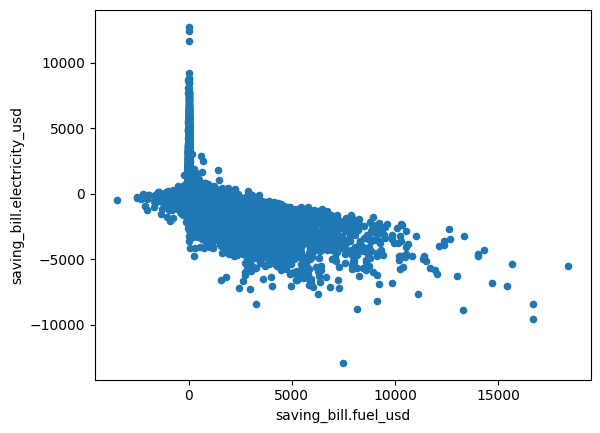

In [294]:
dfp[["saving_bill.fuel_usd", 'saving_bill.electricity_usd']].plot(
    kind="scatter", 
    x="saving_bill.fuel_usd",
    y = 'saving_bill.electricity_usd'
)

<Axes: xlabel='saving_energy.fuel_mmbtu', ylabel='saving_energy.electricity_kwh'>

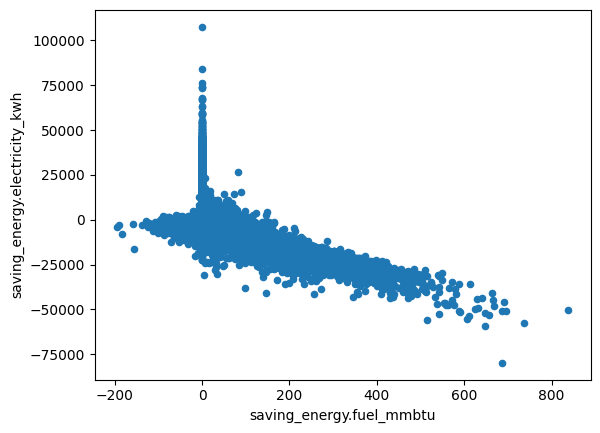

In [296]:
dfp[["saving_energy.fuel_mmbtu", 'saving_energy.electricity_kwh']].plot(
    kind="scatter", 
    x="saving_energy.fuel_mmbtu",
    y = 'saving_energy.electricity_kwh'
)

In [291]:
sorted([x for x in dfp.columns if "saving" in x])

['pct_saving_bill.electricity_%',
 'pct_saving_bill.fuel_oil_%',
 'pct_saving_bill.natural_gas_%',
 'pct_saving_bill.propane_%',
 'pct_saving_bill.total_%',
 'pct_saving_emission.electricity_%',
 'pct_saving_emission.fuel_oil_%',
 'pct_saving_emission.natural_gas_%',
 'pct_saving_emission.propane_%',
 'pct_saving_emission.total_%',
 'pct_saving_energy.electricity_%',
 'pct_saving_energy.fuel_oil_%',
 'pct_saving_energy.natural_gas_%',
 'pct_saving_energy.propane_%',
 'pct_saving_energy.total_%',
 'saving_bill.electricity_usd',
 'saving_bill.fuel_oil_usd',
 'saving_bill.natural_gas_usd',
 'saving_bill.propane_usd',
 'saving_bill.total_usd',
 'saving_emission.electricity_kgCO2e',
 'saving_emission.fuel_oil_kgCO2e',
 'saving_emission.natural_gas_kgCO2e',
 'saving_emission.propane_kgCO2e',
 'saving_emission.total_kgCO2e',
 'saving_energy.electricity_kwh',
 'saving_energy.fuel_oil_mmbtu',
 'saving_energy.natural_gas_therm',
 'saving_energy.propane_mmbtu',
 'saving_energy.total_mmbtu']